Assignment: K-Means Clustering from Scratch

Student Name: Vineeth Chandra Sai Kandukuri Course: CMPE 255

Objective

To implement the K-Means clustering algorithm from first principles using Python and NumPy, without relying on sklearn.cluster.KMeans for the core logic.

Algorithm Overview

    Initialization: Randomly select K data points as initial centroids.

    Assignment: Assign each data point to the nearest centroid (using Euclidean distance).

    Update: Recalculate the centroids by taking the mean of all points assigned to that cluster.

    Convergence: Repeat steps 2 and 3 until centroids do not change significantly or a maximum iteration count is reached.

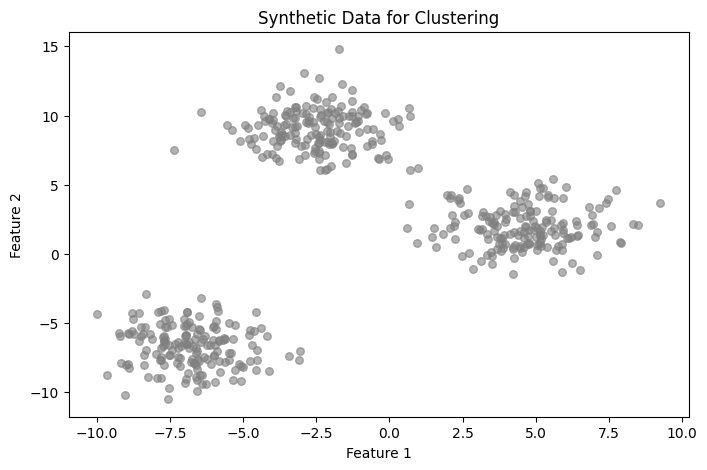

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

# Set seeds for reproducibility
np.random.seed(42)

# 1. Generate Synthetic Data
# We create 3 distinct clusters to test our algorithm
X, y_true = make_blobs(n_samples=500, centers=3, n_features=2, cluster_std=1.5, random_state=42)

# Visualize the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray', alpha=0.6)
plt.title("Synthetic Data for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [2]:
class KMeansScratch:
    """
    A custom implementation of K-Means clustering.
    """
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        """
        Args:
            k (int): Number of clusters.
            max_iters (int): Maximum number of iterations to run.
            tol (float): Tolerance for convergence (centroid movement).
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None

    def fit(self, X):
        """
        Compute k-means clustering.
        """
        n_samples, n_features = X.shape

        # Step 1: Initialize Centroids
        # We randomly pick 'k' samples from the dataset as initial centroids
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            # Step 2: Assign clusters
            # Calculate distance from every point to every centroid
            # distances shape: (n_samples, k)
            distances = self._calculate_euclidean_distances(X, self.centroids)

            # Assign point to the closest centroid (index of min distance)
            self.labels = np.argmin(distances, axis=1)

            # Step 3: Update Centroids
            new_centroids = np.zeros((self.k, n_features))
            for cluster_idx in range(self.k):
                # Get all points belonging to this cluster
                cluster_points = X[self.labels == cluster_idx]

                # If a cluster is empty (rare), keep the old centroid or re-initialize
                if len(cluster_points) == 0:
                    new_centroids[cluster_idx] = self.centroids[cluster_idx]
                else:
                    new_centroids[cluster_idx] = cluster_points.mean(axis=0)

            # Step 4: Check for Convergence
            # If centroids haven't moved more than 'tol', we are done
            centroid_shift = np.linalg.norm(self.centroids - new_centroids)
            if centroid_shift < self.tol:
                print(f"Converged at iteration {i}")
                break

            self.centroids = new_centroids

    def _calculate_euclidean_distances(self, X, centroids):
        """
        Vectorized Euclidean distance calculation.
        Returns matrix of shape (n_samples, k)
        """
        # Expand dimensions to use broadcasting
        # X[:, np.newaxis] shape: (n_samples, 1, n_features)
        # centroids shape: (k, n_features)
        # Difference shape: (n_samples, k, n_features)
        return np.sqrt(np.sum((X[:, np.newaxis] - centroids) ** 2, axis=2))

    def predict(self, X):
        """
        Predict the closest cluster each sample in X belongs to.
        """
        distances = self._calculate_euclidean_distances(X, self.centroids)
        return np.argmin(distances, axis=1)

Converged at iteration 11


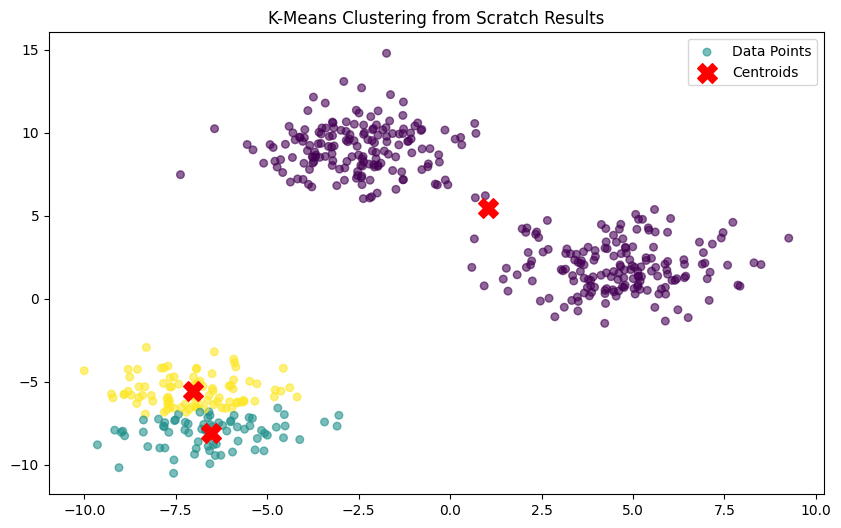

In [3]:
# Instantiate and fit the model
kmeans = KMeansScratch(k=3, max_iters=100)
kmeans.fit(X)

# Get the cluster labels
labels = kmeans.predict(X)

# Visualization
plt.figure(figsize=(10, 6))

# Plot the data points colored by their cluster
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.6, label='Data Points')

# Plot the final centroids
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clustering from Scratch Results")
plt.legend()
plt.show()

In [4]:
from sklearn.cluster import KMeans

# Run standard implementation
sklearn_kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
sklearn_kmeans.fit(X)

# Compare centroids
print("My Custom Centroids:\n", np.sort(kmeans.centroids, axis=0))
print("\nScikit-Learn Centroids:\n", np.sort(sklearn_kmeans.cluster_centers_, axis=0))

# Note: The order of rows might differ, so we sort them for visual comparison.

My Custom Centroids:
 [[-7.02661344 -8.07638965]
 [-6.54050566 -5.55614246]
 [ 1.04292436  5.47821296]]

Scikit-Learn Centroids:
 [[-6.80698643 -6.69480836]
 [-2.5154558   1.91117599]
 [ 4.60130453  9.04524994]]
